In [88]:
from analyses import parse
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import numpy as np
import colorir as cl
from pathlib import Path

In [81]:
# These sims should contain a single cell!!
sim_paths = {}
for sp in Path("../runs/msd/").iterdir():
    sim_type = sp.name
    gamma = 20 - int(sim_type.split("-")[1])
    for p in sp.iterdir():
        replica = int(p.name)
        sim_paths[(gamma, replica)] = p
    
sims = parse.parse_cells_multiple(
    sim_paths.values(),
    n_workers=24
)
celldf = pl.concat([sim.with_columns(gamma=k[0], replica=k[1]) for k, sim in zip(sim_paths, sims)])
celldf

index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,time,wtime,gamma,replica
u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,u32,i32,i32,i32
0,0,200,200,186,180,240.722229,169.056458,240.760757,169.0056,82758,162,11,3100010,3200000,20,7
0,0,200,200,186,180,240.662231,168.846451,240.699921,168.795013,82792,162,11,3100020,3200000,20,7
0,0,200,200,184,180,240.737228,168.931458,240.774277,168.879013,82770,162,11,3100030,3200000,20,7
0,0,199,200,186,180,240.278595,168.991425,240.314865,168.939941,82425,162,11,3100040,3200000,20,7
0,0,199,200,188,180,240.06749,169.046738,240.098358,168.996597,82451,162,11,3100050,3200000,20,7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,200,200,186,180,146.449677,50.311989,146.42395,50.286579,110618,73,169,1899960,1900000,12,8
0,0,200,200,178,180,146.484665,50.171989,146.457123,50.146412,110623,73,169,1899970,1900000,12,8
0,0,201,200,184,180,146.427536,50.205959,146.400253,50.179684,111185,73,169,1899980,1900000,12,8


In [82]:
displdf = celldf.select(
    "gamma",
    "replica",
    "time",
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
).sort(["gamma", "replica", "time"])
displdf

gamma,replica,time,displ
i32,i32,u32,f32
8,0,0,544.465942
8,0,10,543.031433
8,0,20,541.753479
8,0,30,540.837708
8,0,40,540.232117
…,…,…,…
20,20,4999960,59.887749
20,20,4999970,59.999653
20,20,4999980,59.878807


In [83]:
interval = 10_000
dts = np.concat([
    [10], 
    np.arange(
        interval,
        1_000_000 + interval,
        interval,
        dtype=int
    )
])
dts

array([     10,   10000,   20000,   30000,   40000,   50000,   60000,
         70000,   80000,   90000,  100000,  110000,  120000,  130000,
        140000,  150000,  160000,  170000,  180000,  190000,  200000,
        210000,  220000,  230000,  240000,  250000,  260000,  270000,
        280000,  290000,  300000,  310000,  320000,  330000,  340000,
        350000,  360000,  370000,  380000,  390000,  400000,  410000,
        420000,  430000,  440000,  450000,  460000,  470000,  480000,
        490000,  500000,  510000,  520000,  530000,  540000,  550000,
        560000,  570000,  580000,  590000,  600000,  610000,  620000,
        630000,  640000,  650000,  660000,  670000,  680000,  690000,
        700000,  710000,  720000,  730000,  740000,  750000,  760000,
        770000,  780000,  790000,  800000,  810000,  820000,  830000,
        840000,  850000,  860000,  870000,  880000,  890000,  900000,
        910000,  920000,  930000,  940000,  950000,  960000,  970000,
        980000,  990

In [86]:
msddf = pl.DataFrame()
for dt in dts:
    filterdf = displdf.filter(pl.col("time") % dt == 0)
    msd = filterdf\
        .group_by(["gamma", "replica"])\
        .agg(
            msd=(pl.col("displ").diff() ** 2).mean()
        )\
        .with_columns(dt=dt)
    msddf = pl.concat([msddf, msd])
msddf

gamma,replica,msd,dt
i32,i32,f32,i64
20,0,0.067179,10
8,10,0.193196,10
12,18,0.099531,10
8,12,0.209021,10
20,17,0.063211,10
…,…,…,…
8,8,47693.800781,1000000
8,16,56117.242188,1000000
8,15,54024.496094,1000000


In [110]:
aggdf = msddf.group_by(["gamma", "dt"]).agg(
    mean=pl.col("msd").mean(),
    med=pl.col("msd").median(),
    min=pl.col("msd").min(),
    max=pl.col("msd").max(),
    std1=pl.col("msd").mean() + 1.5 * pl.col("msd").std(),
    std2=pl.col("msd").mean() - 1.5 * pl.col("msd").std()
).sort("dt").with_columns(
    pl.exclude(["gamma", "replica"]).log().name.prefix("ln_")
)
aggdf

gamma,dt,mean,med,min,max,std1,std2,ln_dt,ln_mean,ln_med,ln_min,ln_max,ln_std1,ln_std2
i32,i64,f32,f32,f32,f32,f32,f32,f64,f32,f32,f32,f32,f32,f32
12,10,0.102291,0.099531,0.09308,0.127879,0.114281,0.090301,2.302585,-2.279934,-2.307284,-2.374298,-2.056668,-2.169095,-2.404606
8,10,0.203908,0.197798,0.159929,0.240061,0.238265,0.169551,2.302585,-1.590086,-1.620508,-1.833023,-1.426863,-1.434371,-1.774601
20,10,0.069464,0.069135,0.061977,0.076587,0.075066,0.063863,2.302585,-2.66694,-2.671693,-2.780991,-2.569329,-2.589393,-2.751011
8,10000,837.905029,816.128235,569.244141,1163.921509,1066.406494,609.403625,9.21034,6.730905,6.704572,6.34431,7.059551,6.97205,6.412481
20,10000,106.905785,110.925034,83.617943,129.288895,125.120476,88.691093,9.21034,4.671948,4.708855,4.426259,4.86205,4.829278,4.48516
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,990000,16592.314453,14461.633789,11844.033203,25511.054688,23123.121094,10061.508789,13.80546,9.716696,9.579255,9.37958,10.146868,10.04859,9.216474
12,990000,30726.464844,29192.845703,20093.210938,45315.816406,40033.21875,21419.710938,13.80546,10.332881,10.28168,9.908138,10.721413,10.597466,9.972068
12,1000000,30725.919922,28960.445312,21872.058594,45309.195312,39757.535156,21694.304688,13.815511,10.332863,10.273687,9.992967,10.721266,10.590555,9.984806


In [90]:
palette = cl.StackPalette().load("carnival")
grad = cl.PolarGrad(palette, domain=[0, 20])
palette

/tmp/ipykernel_1752701/3214442565.py:1: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



     #e7f8bf
     #98d5a4
     #3faf99
     #008692
     #005986
     #3b2179
     #823083
     #b75687
     #dd867f
     #f4bc77
     #f8f68b

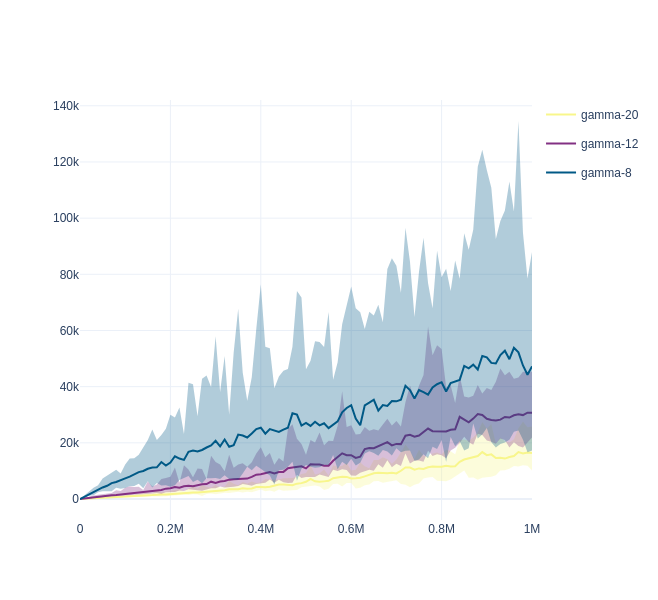

In [113]:
fig = go.Figure()
for gamma, group in aggdf.group_by("gamma"):
    gamma = gamma[0]
    color = grad(gamma)
    fig.add_traces([
        go.Scatter(
            x=group["dt"],
            y=group["mean"],
            mode="lines",
            line_color=color,
            name=f"gamma-{gamma}",
            legendgroup=gamma
        ),
        go.Scatter(
            x=pl.concat([group["dt"], group["dt"][::-1]]),
            y=pl.concat([group["min"], group["max"][::-1]]),
            mode="lines",
            line_color="rgba(0, 0, 0, 0)",
            fillcolor=color,
            opacity=0.3,
            fill="toself",
            hoverinfo="skip",
            showlegend=False,
            legendgroup=gamma
        )
    ])
fig.update_layout(
    template="plotly_white",
    width=400,
    height=600
)

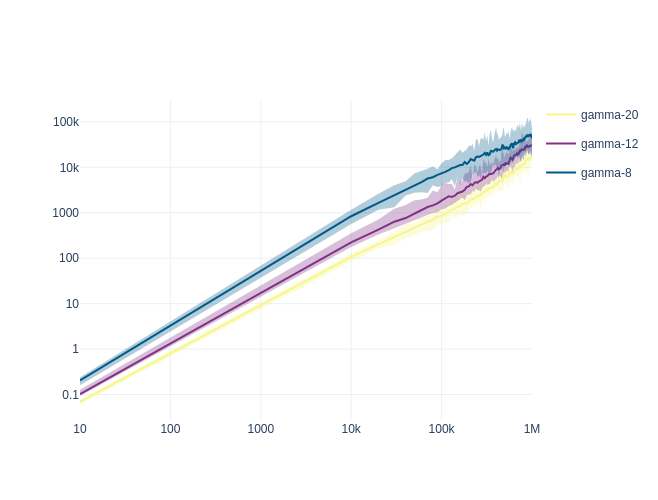

In [114]:

fig.update_layout(
    xaxis_type="log",
    yaxis_type="log",
    width=500,
    height=500
)